# Solution of Time-Dependent Schrödinger Equation 

We try to solve time-dependent Schrödinger equation(TDSE). First of all, the equation is
$$
i\hbar \frac{\partial}{\partial t}\lvert\Psi(t)\rangle=H\lvert\Psi(t)\rangle
$$
when we do calculations, we set $\hbar=1$.  
For the time-dependent case, it is common to use a time-evolution form:
$$
\Psi(t)=e^{-itH}\psi(0)\equiv U(t)\psi(0)
$$
The important part is the implementation of time-evolution calculator. Here we adopt the Trotter-Suzuki formula.  

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm

# constant
PI = np.arccos(-1.)

set some parameters

In [11]:
# mesh grid
numL = 1024
numK = 513
delta = 0.1

# shape of incident wave packet
scale = [6., 6.]
loc = [25., 25.7]
k = 5# wave vector

# shape of slit 
width = int(1 / delta)# aperture
length = int(5 / delta)# thickness
leftEdge = 530
downEdge = 250

# delta time
tau = 0.03125

# time step
t_step = 6000

# others 
isThereDivision = 0

For the initialization, we generate 1024x513 grid points and make the wave equation discrete,
$$
\Psi=e^{(-x\delta-locx)/(2\sigma_x)^2 + (-y\delta-locy)/(2\sigma_y)^2} e^{ixk\delta}
$$
Here x and y are running indices, i is the imaginary unit. $\delta$ represents the lattice spacing.

In [3]:
def init(x,y):
    psi = np.exp(
            -(x * delta - loc[0]) ** 2 / (4 * scale[0] ** 2)
            -(y * delta - loc[1]) ** 2 / (4 * scale[1] ** 2) 
            + complex(0,1) * k * x * delta)

    psi = psi / np.sum((np.abs(psi) * delta) ** 2)
    # the following is correct?
    # psi = psi / np.sqrt((np.sum(np.abs(psi) ** 2) * delta ** 2))

    return psi

Then we write the time-evolution function, firstly we define
$$
\lvert\Psi(t)\rangle=\sum_{l=1}^{L_x}\sum_{k=1}^{L_y}\lvert\Psi_{l,k}(t)\rangle c_{l,k}^\dagger \lvert0\rangle
$$
According to the Trotter-Suzuki formula, we can write $H$ from $A_1$ to $A_9$, 
$$
U(\tau)=e^{-i\tau A_1}e^{-i\tau A_2}e^{-i\tau A_3}e^{-i\tau A_4}e^{-i\tau A_5}e^{-i\tau A_6}e^{-i\tau A_7}e^{-i\tau A_8}e^{-i\tau A_9}
$$
here is the code implementation:

In [4]:
def evolution(psi):
    # some useful function
    # for exp(-i tau A9)
    def expAsScale(psi, alpha):
        return psi * np.exp(-complex(0,1) * tau * alpha)

    # for exp(-i tau A1-8)
    def expAsCrossing(psi, alpha, axis, index, dl = 0, dk = 0):

        if isThereDivision:
            alphaD = alpha
        else:
            alphaD = 1.

        psi_tmp = np.empty((numL, numK), dtype = complex) 

        tau_alpha = tau * alpha

        if not axis:
            # axis = 0, crossing between [l,...] and [l+dl,...]
            for l in index:
                psi_tmp[l, ...] = np.cos(tau_alpha) * psi[l, ...] 
                + complex(0, 1) * np.sin(tau_alpha) / alphaD * psi[l + dl, ...]
                psi_tmp[l + dl, ...] = np.cos(tau_alpha) * psi[l + dl, ...] 
                + complex(0, 1) * np.sin(tau_alpha) / alphaD * psi[l, ...]
        else:
            # axis = 1
            for k in index:
                psi_tmp[..., k] = np.cos(tau_alpha) * psi[..., k] 
                + complex(0, 1) * np.sin(tau_alpha) / alphaD * psi[..., k + dk]
                psi_tmp[..., k + dk] = np.cos(tau_alpha) * psi[..., k + dk] 
                + complex(0, 1) * np.sin(tau_alpha) / alphaD * psi[..., k]

        psi = psi_tmp

        return psi

    
    def idxOutofSome(num, len, loc, dx):
        num -= dx
        loc -= 1

        return np.arange(num // len + (num % len > loc)) * len + loc
    # example
    # num = 13, np.arange(num) = [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
    # len = 4, dx = 2
    #   loc = 1
    #       idxOutofSome = [0 4 8]
    #   loc = 4
    #       idxOutofSome = [3 7], because 7 + len = 11， 11 + dx = 13 exceed!


    # some index
    indexL_odd = idxOutofSome(num = numL, len = 2, loc = 1, dx = 1)
    indexK_odd = idxOutofSome(num = numK, len = 2, loc = 1, dx = 1)
    
    indexL_even = idxOutofSome(num = numL, len = 2, loc = 2, dx = 1)
    indexK_even = idxOutofSome(num = numK, len = 2, loc = 2, dx = 1)

    indexL_12 = np.sort(np.concatenate(
        (idxOutofSome(num = numL, len = 4, loc = 1, dx = 2),
        idxOutofSome(num = numL, len = 4, loc = 2, dx = 2)) ))
    indexK_12 = np.sort(np.concatenate(
        (idxOutofSome(num = numK, len = 4, loc = 1, dx = 2),
        idxOutofSome(num = numK, len = 4, loc = 2, dx = 2)) ))

    indexL_34 = np.sort(np.concatenate(
        (idxOutofSome(num = numL, len = 4, loc = 3, dx = 2),
        idxOutofSome(num = numL, len = 4, loc = 4, dx = 2)) ))
    indexK_34 = np.sort(np.concatenate(
        (idxOutofSome(num = numK, len = 4, loc = 3, dx = 2),
        idxOutofSome(num = numK, len = 4, loc = 4, dx = 2)) ))

    # two kinds of alpha
    a_48 = 1.0 / (48. * (PI * delta) ** 2)
    a_3 = -1.0 / (3. * (PI * delta) ** 2)

    # exp(-i tau A9)
    psi = expAsScale(psi, alpha = 60.*a_48)
    
    # exp(-i tau A8) even
    psi = expAsCrossing(psi, alpha = a_3, axis = 1, index = indexK_even, dk = 1)
    
    # exp(-i tau A7) odd
    psi = expAsCrossing(psi, alpha = a_3, axis = 1, index = indexK_odd, dk = 1)
    
    # exp(-i tau A6) 12[34]
    psi = expAsCrossing(psi, alpha = a_48, axis = 1, index = indexK_34, dk = 2)

    # exp(-i tau A5) [12]34
    psi = expAsCrossing(psi, alpha = a_48, axis = 1, index = indexK_12, dk = 2)

    # exp(-i tau A4) even
    psi = expAsCrossing(psi, alpha = a_3, axis = 0, index = indexL_even, dl = 1)

    # exp(-i tau A3) even
    psi = expAsCrossing(psi, alpha = a_3, axis = 0, index = indexL_odd, dl = 1)

    # exp(-i tau A2) 12[34]
    psi = expAsCrossing(psi, alpha = a_48, axis = 0, index = indexL_34, dl = 2)

    # exp(-i tau A1) [12]34
    psi = expAsCrossing(psi, alpha = a_48, axis = 0, index = indexL_12, dl = 2)
    
    return psi

We need consider boundary condition, since the wave is required to pass through a slit in the setup, part of it will be blocked.

When encountering a boundary, the wave function is given by the superposition of the incident wave function and the reflected wave function.

Taking the half-wave loss into account, the phase difference is $\pi$, from which we obtain:

In [5]:
def boundaryReflection(psi, leftloc = 530, downloc = 250, width = 10, thickness = 50):
    depth = 3

    lEdge = leftloc
    rEdge = leftloc + thickness - 1

    dEdge = downloc
    uEdge = downloc + width - 1

    hEdgeIndex = np.arange(lEdge, rEdge + 1)
    vEdgeIndex = np.concatenate((np.arange(dEdge + 1), np.arange(uEdge + 1, numK)))

    # left and righe edge
    # for [silt edge_around, vEdgeIndex] points，reflect the value outside and set 0 inside
    for l in np.arange(depth):
        # left edge
        psi[lEdge - (l + 1), vEdgeIndex] += -psi[lEdge + l, vEdgeIndex]
        psi[lEdge + l, vEdgeIndex] = 0
        # right edge
        psi[rEdge + (l + 1), vEdgeIndex] += -psi[rEdge - l, vEdgeIndex]
        psi[rEdge - l, vEdgeIndex] = 0

    # up and down edge
    # for [hEdgeIndex, silt edge_around] points
    for k in np.arange(depth):
        # up edge
        psi[hEdgeIndex, uEdge - (k + 1)] += -psi[hEdgeIndex, uEdge + k]
        psi[hEdgeIndex, uEdge + k] = 0
        # down edge
        psi[hEdgeIndex, dEdge + (k + 1)] += -psi[hEdgeIndex, dEdge - k]
        psi[hEdgeIndex, dEdge - k] = 0

    return psi

Then we define a 3-dimension ploting function to visualize the results

In [6]:
def show3dFigure(x, y, z, angle = [45, 0]):
    z_abs = np.abs(z)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

    # Plot the surface.
    surf = ax.plot_surface(x, y, z_abs, cmap=cm.coolwarm,
                        linewidth=0, antialiased=False)

    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax.view_init(elev = angle[0], azim = angle[1])

    plt.show()

Below are the 3D visualizations of the initial wave function, the evolved wave function, and the wave function after applying the boundary conditions.

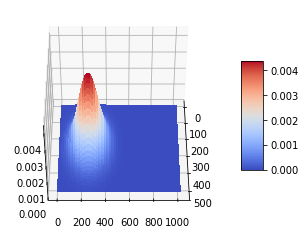

In [7]:
lIndex = np.arange(numL)
kIndex = np.arange(numK)
lIndex, kIndex = np.meshgrid(kIndex, lIndex)

psi0 = init(lIndex, kIndex)

angle = [45, 0]
show3dFigure(lIndex, kIndex, np.abs(psi0), angle)

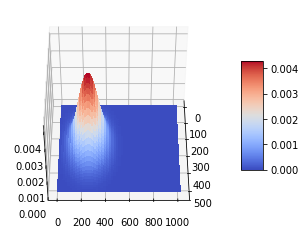

In [8]:
show3dFigure(lIndex, kIndex, np.abs(evolution(psi0)), angle)

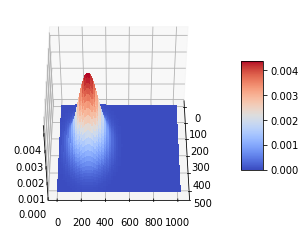

In [9]:
show3dFigure(lIndex, kIndex, np.abs(boundaryReflection(psi0)), angle)

However, the wave packet does not propagate. Different time steps and values of $\tau$ were tested, yet no motion of the wave packet was observed. 

In addition, the normalization condition of the wave packet appears to be violated during the iteration process.

In [15]:
psit = psi0.copy()
psit = psit / np.sqrt(np.sum(np.abs(psit) ** 2) *delta ** 2)
print(r"sum(|psi|^2*delta^2)")
print(np.sum(np.abs(psit) ** 2) *delta ** 2, '0')

t_step = 10

for i in np.arange(t_step):
    psit = evolution(psit)
    psit = boundaryReflection(psit)
    print(np.sum(np.abs(psit) ** 2) *delta ** 2, i + 1)

sum(|psi|^2*delta^2)
1.0000000000000002 0
0.9561705274129821 1
0.9142664376830145 2
0.8741987910202142 3
0.8358871054677914 4
0.7992544261836746 5
0.7642271708650119 6
0.7307349819469415 7
0.6987105852787259 8
0.6680896549933976 9
0.6388106842994865 10


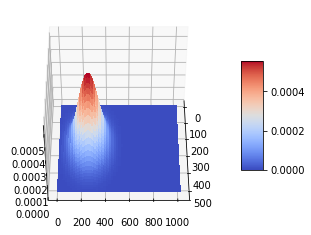

In [10]:
psit = psi0.copy()

t_step = 100

for i in np.arange(t_step):
    psit = evolution(psit)
    psit = boundaryReflection(psit)

show3dFigure(lIndex, kIndex, psit)

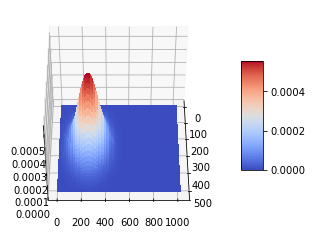

In [584]:
psit = psi0.copy()

tau = 0.03
t_step = 100

for i in np.arange(t_step):
    psit = evolution(psit)
    psit = boundaryReflection(psit, leftloc = 430)

show3dFigure(lIndex, kIndex, psit)

Tip: the code takes too much time.

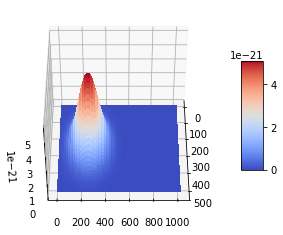

In [585]:
psit = psi0.copy()

tau = 0.03
t_step = 2000

for i in np.arange(t_step):
    psit = evolution(psit)
    psit = boundaryReflection(psit)

show3dFigure(lIndex, kIndex, psit)